In [1]:
# TODO:
# - load 1D test data
# - error vs sigma (2 cases)
# - error vs n_eval (2 cases)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from smooth_POD_ROM.post_processing import richardson_lucy
# from scipy.linalg import svd, orth, qr
# from scipy.optimize import curve_fit
# from numpy import sin, cos, pi
# cmap = plt.cm.plasma
# from scipy.ndimage import gaussian_filter1d, gaussian_filter
# from scipy.signal import wiener
# from scipy.signal import wiener, butter, freqs, convolve, freqz
# from scipy.fft import fft, ifft, fftshift, ifftshift, fftfreq
# from scipy.interpolate import (RegularGridInterpolator, RectBivariateSpline,
#                                interpn, griddata, Rbf, interp1d, interp2d)
# import cv2
# from scipy.signal import convolve2d as conv2
# from skimage import color, data, restoration

In [15]:
pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/Pulse/"
X_test = np.load(pth+"X_test.npy")
X_test_s = np.load(pth+"X_test_s.npy")
X_test_intp = np.load(pth+"X_test_intp.npy")
X_test_intp_s = np.load(pth+"X_test_intp_s.npy")
n_x = len(X_test[:, 0])
dx = 1/n_x
x = np.linspace(0, 1, n_x, endpoint=False) + dx/2

In [36]:
np.linspace(0, 0.1, 21)

array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ,
       0.045, 0.05 , 0.055, 0.06 , 0.065, 0.07 , 0.075, 0.08 , 0.085,
       0.09 , 0.095, 0.1  ])

In [58]:
sgms = np.linspace(0, 0.2, 41)
num_iters = [1, 2, 5, 10, 15, 20, 30, 40, 50, 100, 200, 500, 1000, 2000]
e1_ = np.empty((len(sgms), len(num_iters), len(X_test[0])))
e2_ = np.empty((len(sgms), len(num_iters), len(X_test[0])))
for i, sgm in enumerate(sgms):
    for j, num_iter in enumerate(num_iters):
        print(i, j, sgm, num_iter)
        for k in range(len(X_test[0])):
#             sgm = 0.05
#             num_iter = 500
            deconvolved = richardson_lucy(x, X_test_intp_s[:, k], sgm, num_iter, truth=None, damping=2)
            e1_[i, j, k] = np.mean((X_test_intp[:, k]-deconvolved)**2)**.5
            e2_[i, j, k] = np.mean((X_test[:, k]-deconvolved)**2)**.5
            print(e1_[i, j, k], e2_[i, j, k])
#             plt.plot(X_test[:, j])
#             plt.plot(X_test_intp[:, j])
#             plt.plot(X_test_s[:, j])
#             plt.plot(X_test_intp_s[:, j])
#             plt.plot(deconvolved)
#             plt.show()
e1 = np.mean(e1_, axis=-1)
e2 = np.mean(e2_, axis=-1)

0 0 0.0 1
0.10602309934022443 0.2061667663378976
0.11798127115249248 0.1972951433675818
0.12420281554416979 0.19273139670209324
0.13140751036022078 0.1875808860680582
0.14817431825357094 0.17664780134888675
0.16728019839561098 0.16728019839561098
0 1 0.0 2
0.10602309934022443 0.2061667663378976
0.11798127115249248 0.1972951433675818
0.12420281554416979 0.19273139670209324
0.13140751036022078 0.1875808860680582
0.14817431825357094 0.17664780134888675
0.16728019839561098 0.16728019839561098
0 2 0.0 5
0.10602309934022443 0.2061667663378976
0.11798127115249248 0.1972951433675818
0.12420281554416979 0.19273139670209324
0.13140751036022078 0.1875808860680582
0.14817431825357094 0.17664780134888675
0.16728019839561098 0.16728019839561098
0 3 0.0 10
0.10602309934022443 0.2061667663378976
0.11798127115249248 0.1972951433675818
0.12420281554416979 0.19273139670209324
0.13140751036022078 0.1875808860680582
0.14817431825357094 0.17664780134888675
0.16728019839561098 0.16728019839561098
0 4 0.0 15


0.16546763516226792 0.16546763516226798
2 10 0.01 200
0.10543517686931013 0.20604533139396658
0.11712498618638172 0.1967518011388714
0.12321490380217419 0.19197290625327648
0.13027223096683385 0.18658264734417718
0.14671268587113154 0.17516507213506746
0.16546763549387247 0.1654676354938725
2 11 0.01 500
0.10543024968624658 0.20604574171519177
0.11712336298560692 0.1967523318077868
0.12321382951102879 0.19197320511427954
0.13027158182021073 0.18658269526041132
0.14671255441967138 0.17516506497875442
0.16546764234939976 0.16546764234939976
2 12 0.01 1000
0.10543574755822235 0.2060464537763716
0.11712505758844781 0.19675206694818126
0.12321490659031213 0.19197318766992458
0.1302721881654259 0.18658303216489752
0.14671261380834455 0.17516515438624905
0.16546762320581235 0.1654676232058124
2 13 0.01 2000
0.10544734709737923 0.20604960286297846
0.11712911832901185 0.1967532678337152
0.12321770957507266 0.1919741449646142
0.13027400994785382 0.18658314181473398
0.14671319972599772 0.17516506

0.1377241099577244 0.16616240678356264
0.15436379962342922 0.15436379962342925
5 10 0.025 200
0.10148943976835323 0.2059818132919073
0.11171686173294652 0.19396153207074374
0.11704380035413058 0.1877839995847475
0.12323659077993013 0.1808206019742218
0.137738138055048 0.1661931631299697
0.15436697078583606 0.15436697078583608
5 11 0.025 500
0.10161213431366917 0.2059102797694483
0.11168348618564072 0.1940719961305506
0.11699430794120642 0.1878831289555603
0.12317973162605891 0.180892694867283
0.13768913893429438 0.16619902835900685
0.15436971394896803 0.15436971394896806
5 12 0.025 1000
0.10194866049471016 0.20602599565227017
0.11172933755504648 0.19417873412859485
0.11699699913701304 0.1879260069079792
0.1231520820609593 0.18087544629229033
0.1376364819466744 0.1661254618823324
0.154362505332811 0.154362505332811
5 13 0.025 2000
0.10260824885400005 0.2063742173201109
0.11200452472435193 0.1941566792741979
0.11719907291429041 0.18781528637351455
0.12329286549471809 0.18072216227265747


0.098792730959261 0.1810118419784218
0.10250270282499872 0.1688790702230682
0.11130942602986489 0.1423400755806763
0.12228927617528995 0.12228927617528998
8 9 0.04 100
0.0904134774268602 0.21146973137783442
0.09565933421706938 0.19113269416015313
0.09873664441716552 0.18048985909050974
0.10240397634738621 0.1682482771369659
0.11124248518033018 0.14179994665141055
0.12261726939253563 0.12261726939253564
8 10 0.04 200
0.09103426008835479 0.21105690458218684
0.09605254781536729 0.19104257344226294
0.0990935444828426 0.18035771407258872
0.10273528746272569 0.16808536115428124
0.11156326042333359 0.1417550090812724
0.12270770304156542 0.12270770304156545
8 11 0.04 500
0.09144464197819047 0.21104458597773187
0.09627337799301748 0.19158808339486194
0.09932419618209852 0.1808013315246457
0.10299379548381657 0.16842809100397915
0.11191531731466894 0.14204645949995906
0.12274565492857431 0.12274565492857434
8 12 0.04 1000
0.09149564641679193 0.2115928407060578
0.09611285304607524 0.1922129885537

0.08509106677177292 0.26588193420494866
0.07983172539466542 0.2166702645882682
0.08111385886428134 0.19461898304837663
0.08340944249841684 0.1701919485038023
0.09037104303854349 0.12223605890369756
0.08521234065154451 0.08521234065154452
11 0 0.055 1
0.10275427091819746 0.19641768461302217
0.11160716288000322 0.18611708158612586
0.11634516488461569 0.1807983662096473
0.12192168670001406 0.17478805822585902
0.13524486876489 0.16201671896356198
0.15098070368876076 0.1509807036887608
11 1 0.055 2
0.10229345866428285 0.19000375584480445
0.1085963460072969 0.17857058756260732
0.11205119827126864 0.17262587439476518
0.11617377378639539 0.16588404939530105
0.1262504336596916 0.15143997440801427
0.13855622058601966 0.13855622058601968
11 2 0.055 5
0.10375332281405036 0.18057625666888796
0.10537799686600802 0.166363803442682
0.10630726202071493 0.1588559821364119
0.10742663278184751 0.15027176919897767
0.11021823960040682 0.1315959752219302
0.11426641248305253 0.11426641248305254
11 3 0.055 10


...

0.3055646077301025 0.2180077436339276
0.2784206303263978 0.22420554720957575
0.24699025495509724 0.23687451804719348
0.24925267188625724 0.24925267188625724
30 11 0.15 500
0.3925174553760364 0.30274615280825934
0.4257751643329989 0.330175317070451
0.3931278811245864 0.33755257284590423
0.3680823105450086 0.34479479738517604
0.3611749468205155 0.3587835969204298
0.37222700269843845 0.3722270026984385
30 12 0.15 1000
0.46673844870883313 0.39678011278211484
0.5101445254247639 0.42943296582372387
0.4732158300866927 0.43733002926023173
0.45562444046374684 0.44509086906671663
0.4618664844022704 0.46024167455173426
0.47503323132696845 0.47503323132696845
30 13 0.15 2000
0.5553654066619682 0.5031805717728625
0.6096261397837316 0.5397668024369592
0.5694980439062406 0.5485367307449495
0.5629228899922036 0.5571879931410287
0.5755014358409509 0.5742003866315653
0.5909575734627761 0.5909575734627761
31 0 0.155 1
0.10487757972436519 0.20202774074432667
0.11579500982498996 0.19219017028351776
0.12145

0.12117602303845677 0.1211760230384568
33 5 0.165 20
0.13307831918723756 0.1830514059043043
0.14491365847719612 0.14503138820441377
0.14150045070231929 0.13664496197751252
0.13555809459950624 0.12936356474833935
0.12001287876286156 0.11857077729806412
0.11249511514216826 0.11249511514216827
33 6 0.165 30
0.14660362683649905 0.18250979291912103
0.16753285919893204 0.13511347921108444
0.16207547970602548 0.1257374410687432
0.15221560916999663 0.1180448499458152
0.12403776677641372 0.10763475466451831
0.10253979141063753 0.10253979141063756
33 7 0.165 40
0.15807063146471248 0.18430712852659356
0.18739627085553173 0.13129292658933198
0.18062075019710197 0.12152627335138114
0.16812917207058745 0.11384048324666234
0.13156335822002432 0.10424000580591215
0.100416019716169 0.10041601971616901
33 8 0.165 50
0.16810657443170793 0.18747325727417943
0.20448515162707148 0.13145702045997468
0.19671823331571972 0.12174968949148231
0.1823070400958769 0.1144043117321843
0.14021286444446346 0.1060024815

0.17910726406299077 0.2536149095830608
0.2579981709278557 0.18447259414668407
0.25574357940351305 0.17121848484314103
0.24245830368445045 0.16073053514950028
0.19249787149388908 0.14775398318016714
0.143673397845099 0.143673397845099
35 10 0.17500000000000002 200
0.2133522988584139 0.2949284215673368
0.3209542855478055 0.2247788688877994
0.3194444931919638 0.2137177418576592
0.3018086000138192 0.20643289272827628
0.24124041220373896 0.20161381583431934
0.20584357599704414 0.20584357599704414
35 11 0.17500000000000002 500
0.2869787291733571 0.3663779013791061
0.4112849324907286 0.29562301302924304
0.4140706991852183 0.291141033886445
0.3908316518879517 0.29180378305589305
0.32233367771584814 0.30185263141337065
0.31602227802841465 0.31602227802841465
35 12 0.17500000000000002 1000
0.36054548315739654 0.43413751422456937
0.4854471336687601 0.367519865256814
0.49379998301699446 0.37077176820640856
0.4693759560117252 0.3779649367687657
0.40294414315888816 0.3954313044165912
0.4125776528934

0.48960578396990717 0.48960578396990717
38 0 0.19 1
0.1055288146006425 0.20391898076126747
0.11729540316791688 0.1941984853977779
0.12318165878651902 0.18949833369487779
0.12999090734302823 0.18426599484713352
0.14593037592076272 0.1733861885808101
0.16439961956239374 0.16439961956239374
38 1 0.19 2
0.10607055350298514 0.2025561627432551
0.11733976732101704 0.19160989828119368
0.12280552280683983 0.1867048514988113
0.1291320847852051 0.18133416258750237
0.14407190820296603 0.17042551127952305
0.16175240474680028 0.1617524047468003
38 2 0.19 5
0.11119330212263964 0.20229506035420397
0.12046444546519429 0.18623391651636764
0.12448027770996856 0.1804245812607692
0.12910977787982475 0.1743961456507096
0.14039683674251074 0.16304359340664898
0.15501160891166577 0.15501160891166577
38 3 0.19 10
0.1228501337509805 0.2087524821437325
0.13043551324421324 0.18265355298319164
0.13242802060952 0.1748978946965691
0.13436304146227954 0.16737634958677086
0.1389191196261647 0.15462614741299321
0.14693

0.16295643746645155 0.2630144577739469
0.17634081889436867 0.2153653812490006
0.1791578274494428 0.20136186126686775
0.17970131903969175 0.18818378255179422
0.17217647163401195 0.1675647918370488
0.15570802906780407 0.1557080290678041
40 7 0.2 40
0.17343469349140872 0.2794707992025795
0.18972472173206578 0.22876131669378424
0.194555587205369 0.21359369720472782
0.1962320462185969 0.19913641619457
0.18708353072969244 0.17656616588482937
0.16248859843827917 0.1624885984382792
40 8 0.2 50
0.18163175298646983 0.2919838356933789
0.19998734418552777 0.24062158443897855
0.2070292948009018 0.22497137220233182
0.21026091894040982 0.20988482492146032
0.20067832531501034 0.1860389839458119
0.17003522135731994 0.17003522135731997
40 9 0.2 100
0.20846976952579893 0.32541483580297964
0.23041307508921421 0.2828457973409533
0.24708848409182552 0.2681097110276645
0.25811842342710173 0.2531157625172318
0.250771933522972 0.22639361559118873
0.20434864619823773 0.20434864619823778
40 10 0.2 200
0.23807046

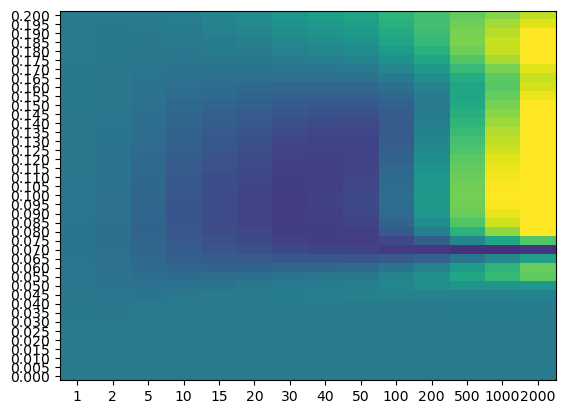

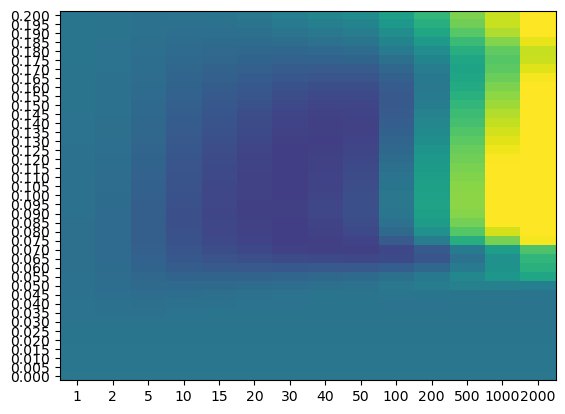

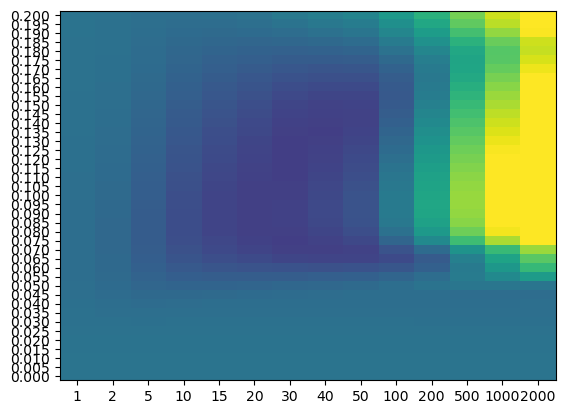

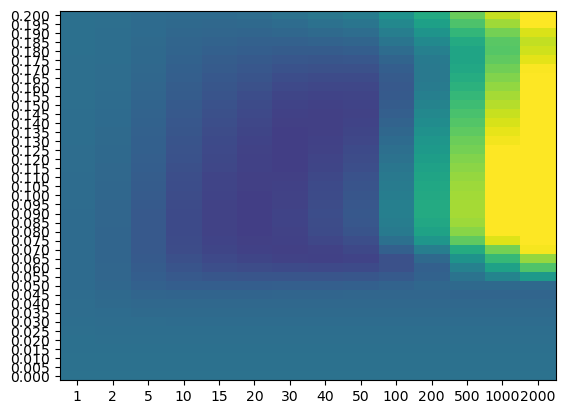

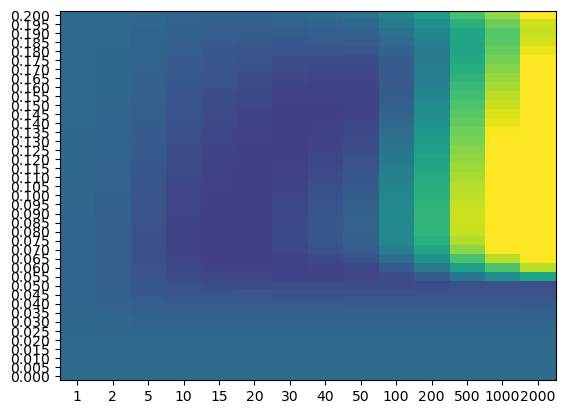

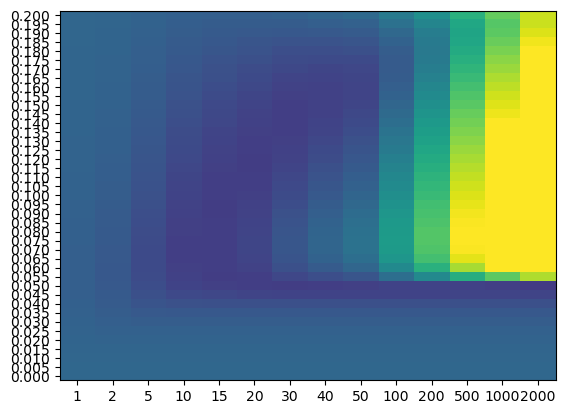

In [60]:

dc = num_iters[1]-num_iters[0]
ds = sgms[1]-sgms[0]
ext = (0, 1, (sgms[0]-ds/2), (sgms[-1]+ds/2))  # num_iters[0]-dc/2, num_iters[-1]+dc/2
xticks = np.linspace(0, 1, len(num_iters), endpoint=False) + 1/len(num_iters)/2
for k in range(len(X_test[0])):
#     fig, ax = plt.subplots()
#     ax.imshow(e1_[:, :, k], interpolation="nearest", origin="lower", extent=ext, vmin=0, vmax=.5)
#     ax.set_xticks(xticks)
#     ax.set_xticklabels(num_iters)
#     ax.set_yticks(sgms)
#     ax.set_aspect("auto")
#     plt.show()

    fig, ax = plt.subplots()
    ax.imshow(e2_[:, :, k], interpolation="nearest", origin="lower", extent=ext, vmin=0, vmax=.5)
    ax.set_xticks(xticks)
    ax.set_xticklabels(num_iters)
    ax.set_yticks(sgms)
    ax.set_aspect("auto")
    plt.show()


In [2]:
sigma = 0.05
m = 400

In [3]:
def bump(x, mu):
    w = 0.075
    y = np.zeros_like(x)
    y[np.abs(x-mu)<w/2] = 1.0
    return y

In [12]:
def richardson_lucy2(im_blur, sgm, num_iter=50, clip=True, filter_epsilon=None):
    psf_f = gaussian_f(sgm, m)    
    im_deconv = im_blur.copy()

    # Small regularization parameter used to avoid 0 divisions
    eps = 1e-12

    for _ in range(num_iter):
        blurred = convolve_f(im_deconv, psf_f) + eps
        if filter_epsilon:
            relative_blur = np.where(blurred < filter_epsilon, 0, im_blur / blurred)
        else:
            relative_blur = im_blur / blurred
        im_deconv *= convolve_f(relative_blur, psf_f)
    if clip:
        im_deconv[im_deconv > 1] = 1
        im_deconv[im_deconv < -1] = -1

    return im_deconv

def richardson_lucy(x, im_blur, sgm, num_iter=50, truth=None, damping=2):
    #assert len(im_blur.shape)==2, "image needs to be 2D"
    dx = x[1]-x[0]
    im_deconv = im_blur.copy()
    eps = 1e-12  # regularization to avoid 0 division
    for _ in range(num_iter):
        #blurred = convolve2d(im_deconv.copy(), psf, boundary='symm', mode='same') + eps
        #blurred = convolve_f2D(im_deconv, psf_f2D) + eps
        blurred = gaussian_filter(im_deconv, sigma=sgm/dx, truncate=8)# + eps
        blurred[np.abs(blurred)<eps] = eps
        relative_blur = im_blur / blurred
        #im_deconv *= convolve2d(relative_blur, psf_mirror, boundary='symm', mode='same')
        #im_deconv *= convolve_f2D(relative_blur, psf_f2D)
        error_estimate = gaussian_filter(relative_blur, sigma=sgm/dx, truncate=8)
        if damping:
            error_estimate[error_estimate>(1+damping)] = 1+damping
            error_estimate[error_estimate<(1-damping)] = 1-damping
        im_deconv *= error_estimate
        if isinstance(truth, np.ndarray):
            print(_, np.mean((truth-im_deconv.ravel())**2)**.5)
    return im_deconv

In [13]:
def convolve_f(y, g_f):
#     # alternative with mode = "wrap"
#     y_smooth2 = gaussian_filter1d(y, sigma/dx, mode="wrap", cval=0, truncate=20)
#     print(np.allclose(y_smooth, y_smooth2))
    y_f = fft(y)
    y_f_smooth = y_f*g_f
    y_smooth = ifft(y_f_smooth)
    return y_smooth.real

def convolve_x():
    return convolve(y, psf, mode='same')

In [14]:
def gaussian(x, sigma, m, shift=True):
    # dont use cv2.getGaussianKernel(m, sigma)[:, 0], we need the gaussian to be centered at one single node!
    if shift:
        x_kernel = fftshift(x)
        offset = x_kernel[0]
    else:
        x_kernel = x
        offset = np.min(np.abs(x))  # or 0?
    A = 1/(m*sigma*(2*np.pi)**.5)
    return A * np.exp(-(x_kernel-offset)**2 / (2 * sigma**2))

def gaussian_f(sigma, m):
    # g_f = fft(g_x)
    # print(np.allclose(g_f, g_f2))
    # plt.plot(g_f, "bo")
    # plt.plot(g_f2, "r.")
    # plt.show()

    # Fourier Transform of the Gaussian by Konstantinos G. Derpanis
    f = np.fft.fftfreq(m, d=1/m)
    omega = 2*np.pi*f
    return np.exp(-omega**2*sigma**2/2)

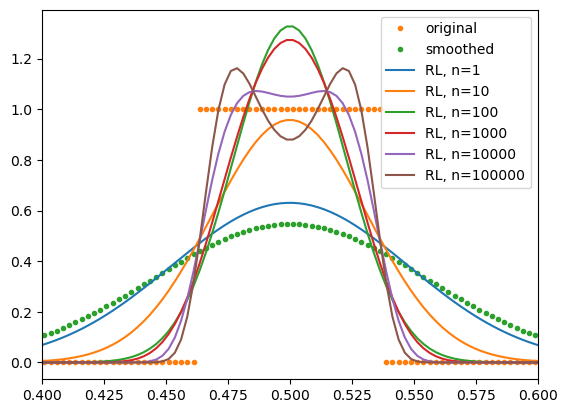

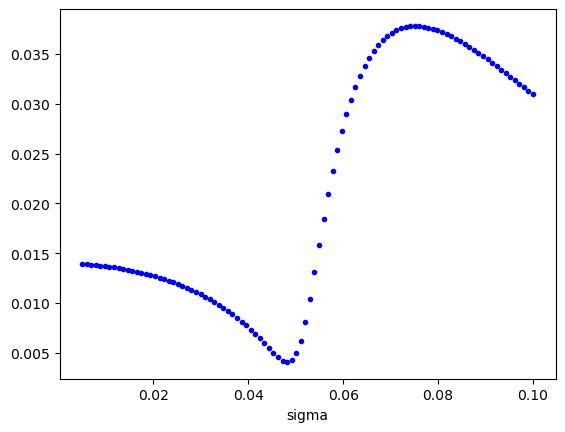

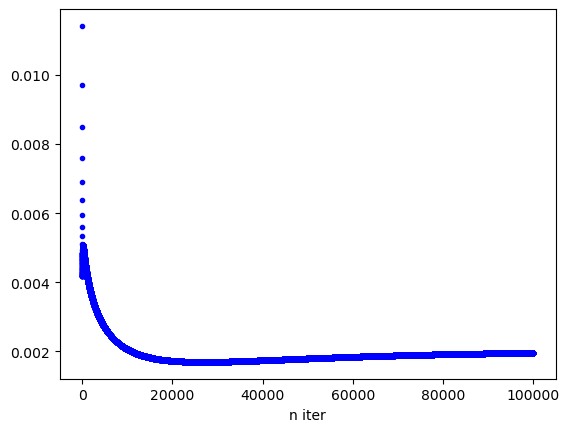

In [17]:
x = np.linspace(0, 1, m)
y = bump(x, 0.5)
#x_kernel = np.linspace(-.5, .5, 99, endpoint=True)
#psf = gaussian(x_kernel, sigma, len(x_kernel), shift=False)
#psf = gaussian(x-0.5, sigma, m, shift=False)
#psf = gaussian(x, sigma, m)

psf_f = gaussian_f(sigma, m)
y2 = convolve_f(y, psf_f)
e = np.empty(100,)
sgms = np.linspace(0.1*sigma, 2*sigma, 100)
for i, sgm in enumerate(sgms):
    y3 = richardson_lucy(x, y2, sgm, num_iter=100)
    e[i] = np.mean((y3-y)**2)*.5
    
plt.plot(x, y, "C1.", label="original")
plt.plot(x, y2, "C2.", label="smoothed")
for n in [1, 10, 100, 1000, 10000, 100000]:
    y3 = richardson_lucy(x, y2, sigma, num_iter=n)  # (x, im_blur, sgm, num_iter=50, truth=None, damping=2)
    plt.plot(x, y3, "-", label="RL, n={:.0f}".format(n))
#plt.plot(x_kernel, psf, "C4.")
plt.legend()
plt.xlim(0.4, 0.6)
plt.show()

plt.plot(sgms, e, "b.")
plt.xlabel("sigma")
plt.show()

num_iter = 100000
e = np.empty(num_iter,)

im_blur = y2
psf_f = gaussian_f(sigma, m)    
im_deconv = im_blur.copy()
for k in range(num_iter):
    blurred = convolve_f(im_deconv, psf_f) + 1e-12
    relative_blur = im_blur / blurred
    im_deconv *= convolve_f(relative_blur, psf_f)
    e[k] = np.mean((im_deconv-y)**2)*.5
plt.plot(np.arange(num_iter), e, "b.")
plt.xlabel("n iter")
plt.show()